Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

Load the Dataset

In [14]:
df = pd.read_csv(r"C:\Users\myjyu\Downloads\Ice Cream.csv")
df.head()

,Temperature,Revenue
0,24.6,535
1,26.1,626
2,27.8,661
3,20.6,488
4,11.6,317


Explore the Data

In [15]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  500 non-null    float64
 1   Revenue      500 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 7.9 KB
None
       Temperature      Revenue
count   500.000000   500.000000
mean     22.281600   522.058000
std       8.097597   175.410399
min       0.000000    10.000000
25%      17.175000   406.000000
50%      22.400000   530.000000
75%      27.800000   643.000000
max      45.000000  1000.000000
Temperature    0
Revenue        0
dtype: int64


Data Visualization

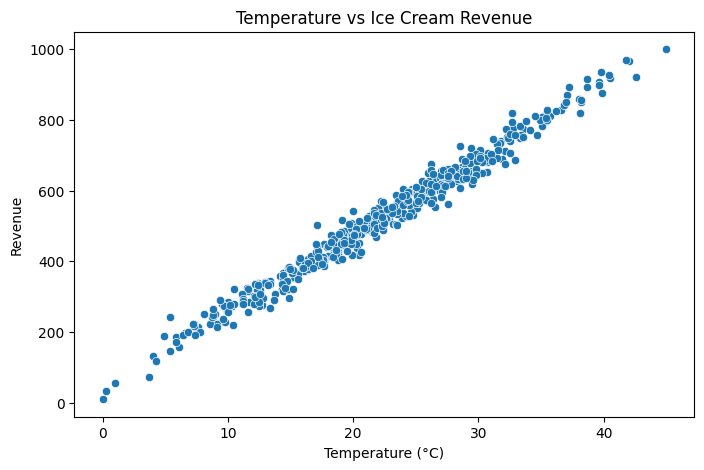

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Temperature", y="Revenue", data=df)
plt.title("Temperature vs Ice Cream Revenue")
plt.xlabel("Temperature (°C)")
plt.ylabel("Revenue")
plt.show()

Prepare Data for Machine Learning

In [17]:
X = df[['Temperature']]
y = df['Revenue']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train the Model

In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Make Predictions

In [20]:
predictions = model.predict(X_test)

Evaluate the Model

In [21]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 19.195652579103704
R2 Score: 0.9771509516333023


Plot Regression Line

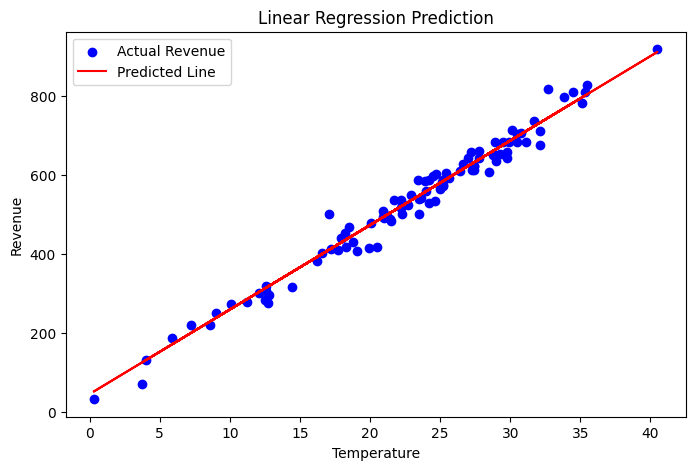

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, color="blue", label="Actual Revenue")
plt.plot(X_test, predictions, color="red", label="Predicted Line")
plt.xlabel("Temperature")
plt.ylabel("Revenue")
plt.title("Linear Regression Prediction")
plt.legend()
plt.show()

Predict New Revenue

In [23]:
temperature = [[35]]
predicted_revenue = model.predict(temperature)

print("Predicted Revenue for 35°C:", predicted_revenue[0])

Predicted Revenue for 35°C: 794.6183713928374


c:\Users\myjyu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Save the Model

In [24]:
import pickle

with open("icecream_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully")

Model saved successfully
